# Astr 324, Spring 2026, University of Washington

# Week 6: Bayesian model selection with MCMC

#### This notebook is available from [github](https://github.com/uw-astr-324/astr-324-s26/blob/main/lectures/Week6.ipynb).

##### Resources for this notebook include:
- [Textbook](https://press.princeton.edu/books/hardcover/9780691198309/statistics-data-mining-and-machine-learning-in-astronomy) Chapters 5 and 8.  
  
 

<a id='toc'></a>

## This notebook includes:

[Model selection example: finding multiple bursts in time series](#MS1mcmc) 

[Bayesian Blocks Algorithm](#MS2mcmc)   

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, cauchy
import scipy.stats as stats  
%matplotlib inline

### In addition to pymc, which we introduced the last time, we will here use another, much more light-weight and very popular in astronomy, tool called "emcee"  

In [1]:
import emcee
import pymc as pm
import arviz as az
import corner 

ModuleNotFoundError: No module named 'emcee'

##  Markov Chain Monte Carlo in Practice: PyMC vs. emcee

Quoting 
[Jake's blog:](http://jakevdp.github.io/blog/2014/06/14/frequentism-and-bayesianism-4-bayesian-in-python/)

### emcee

* The emcee package (also known as MCMC Hammer, which is in the running for best Python package name in history) is a Pure Python package written by Astronomer Dan Foreman-Mackey. It is a lightweight package which implements a fairly sophisticated Affine-invariant Hamiltonian MCMC. Because the package is pure Python (i.e. it contains no compiled extensions) it is extremely easy to install; with pip, simply type at the command-line "pip install emcee".*

* Emcee does not have much specific boilerplate code; it simply requires you to pass it a Python function which returns a value proportional to the log-posterior probability, and returns samples from that posterior.*

### PyMC

* The PyMC package has many more features than emcee, including built-in support for efficient sampling of common prior distributions. PyMC also provides several samplers. Unlike earlier version, it doesn't rely on compiled fortran libraries, and can be easily installed either by pip or conda.

More details about PyMC are available from [the pyMC User Guide](https://docs.pymc.io/)

### Recall "Bayesian Model Comparison" from Lecture 4:

To determine which model is better we compute the ratio of the posterior probabilities or the **odds ratio** for two models as
$$O_{21} \equiv \frac{p(M_2|D,I)}{p(M_1|D,I)}.$$

The posterior probability that the model $M$ is correct given data $D$ is
$$p(M|D,I) = \frac{p(D|M,I)p(M|I)}{p(D|I)},$$
and the odds ratio can ignore $p(D|I)$ since it will be the same for both models. 

We get 
$$O_{21} = \frac{p(D\,|\,M_2,I)\,p(M_2\,|\,I)}{p(D\,|\,M_1,I)\,p(M_1\,|\,I)} \equiv B_{21} \, \frac{p(M_2\,|\,I)}{p(M_1\,|\,I)},$$
where $B_{21}$ is called the Bayes factor. 

The Bayes factor compares how well the models fit the data: it is a ratio of data likelihoods averaged over 
all allowed values of the model parameters and computed as
$$B_{21} = \frac{\int p(D\,|\,M_2, \theta, I) \, p(\theta\,|\,M_2, I) \, d\theta}{\int p(D\,|\,M_1, \theta, I) \, p(\theta\,|\,M_1, I) \, d\theta}. $$
 
In other words, the Bayes factor is the ratio of **the global likelihoods for models $M_1$ and $M_2$**, 
where the global likelihood, or evidence, is a weighted average of the likelihood function, with the 
prior for model parameters acting as the weighting function.




## Example: unknown number of "bursts" in a time series - find out how many bursts are there in the time series and their best-fit model parameters.

### (note: a very similar example is the number of components in a spectrum, such as when searching for new particles in physics, or analyzing samples in biology and chemistry, etc...)

The flux vs. time plot further below shows UV flux measurements for an active M dwarf
star. These stars are known for their exponential bursts of energy, well described
by the profile 
$$\rm{flux(time)} = A\,exp(-\alpha \, t)$$ 
for $t>T$. Find how many bursts were observed for this star during the provided 2 hour 
stretch of data and estimate their amplitudes (A), decay constants ($\alpha$),
and the time of bursts. 

**Additional details:**
- there are no more than 2 bursts in this dataset
- we  can use flat priors for A and T and the background (non-bursting) flux level,
  and Jeffreys' prior for $\alpha$
- we can approximate model comparison based on the BIC 
- we can relatively easily solve this problem by generalizing the astroML code from this example [fig. 10.25](http://www.astroml.org/book_figures/chapter10/fig_matchedfilt_burst.html)

##  Model selection example: finding bursts in time series<a id='MS1mcmc'></a>
[Go to top](#toc)

## Modelling a weak signal on top of background


A bit of motivation: 

![particle](figures/atlas.png)

Let's assume a Gaussian profile (but this can be easily modified) for signals (peaks) and uniform distribution for the background level.

To make things interesting, we'll apply heteroscedastic observational errors -- we'll assume the measurement errors are not uniform.

Let's first generate a mock data set...

In [3]:
def GaussAndBkgd(t, b0, A, sigma, T):
    """Gaussian profile + flat background model"""
    y = b0 + A * np.exp(-(t - T)**2/2/sigma**2)
    return y

np.random.seed(42)
N = 101
b0_true = 10
A_true = 3
sigma_true = 3.0
T_true = 40

t = np.sort(100 * np.random.random(N))
y_true = GaussAndBkgd(t, b0_true, A_true, sigma_true, T_true)
err_y = (0.6+0.5*np.sin(2*np.pi*t/100)) # sinusoidal change of precision
y_obs = np.random.normal(y_true, err_y)

<ErrorbarContainer object of 3 artists>

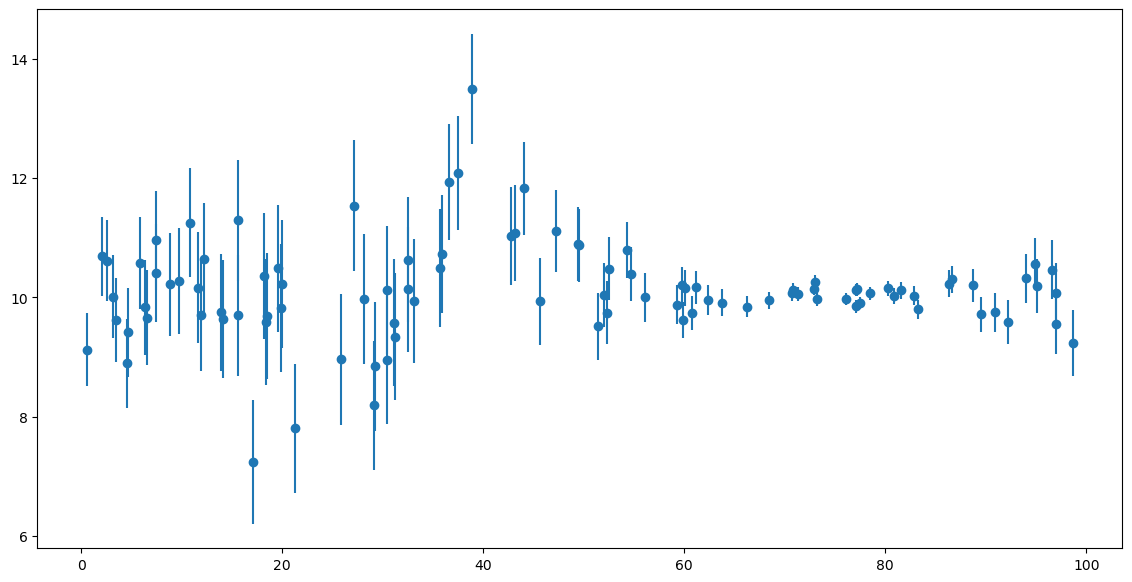

In [4]:
# and let's visualize it
plt.figure(figsize=(14, 7))

# "data" with observational errors.
plt.scatter(t, y_obs)
plt.errorbar(t, y_obs, err_y, fmt='none')

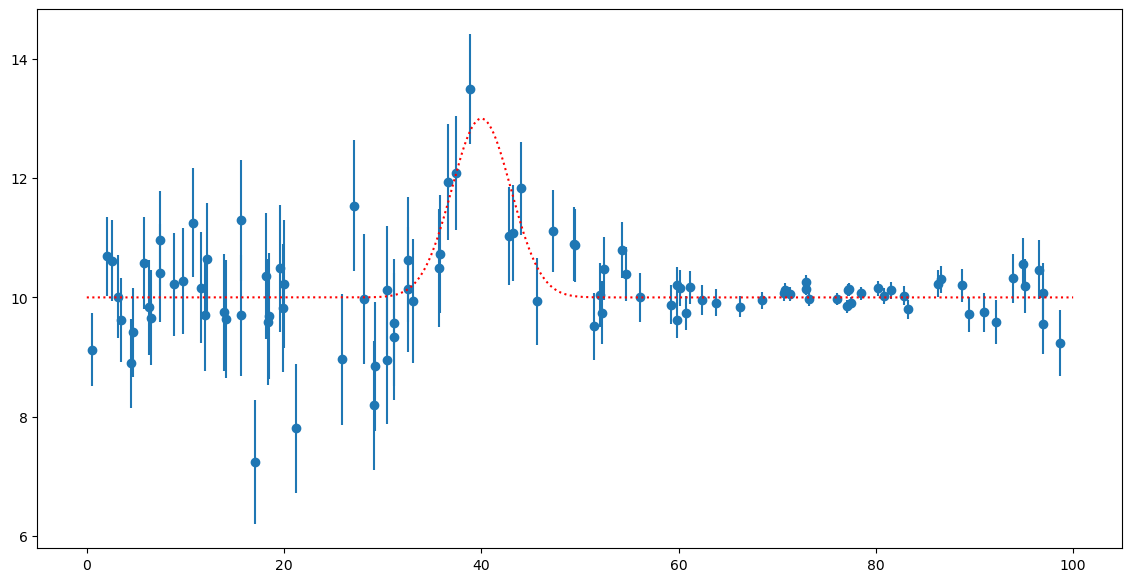

In [5]:
# and let's visualize it
plt.figure(figsize=(14, 7))

# "data" with observational errors.
plt.scatter(t, y_obs)
plt.errorbar(t, y_obs, err_y, fmt='none')

# model
tt = np.linspace(0, 100, 1000)
plt.gca().plot(tt, GaussAndBkgd(tt, b0_true, A_true, sigma_true, T_true), c='red', linestyle=':');

### now let's construct a model and sample it using MCMC 

In [6]:
with pm.Model():
    
    # block with definitions of priors
    b0 = pm.Uniform('b0', 5, 15)
    A = pm.Uniform('A', 0, 10)
    T = pm.Uniform('T', 35, 45)
    # Jeffrey's prior (flat in log space, or 1/sigma)
    log_sigma = pm.Uniform('log_sigma', -1, 3)

    # the main "instruction" that introduces a model (note that t doesn't have uncertainties)
    y = pm.Normal('y', mu=GaussAndBkgd(t, b0, A, np.exp(log_sigma), T), sd=err_y, observed=y_obs)

    step = pm.Metropolis()
    traces = pm.sample(draws=10000, tune=500, step=step, cores=1)
    print('Done')

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [b0]
>Metropolis: [A]
>Metropolis: [T]
>Metropolis: [log_sigma]


Output()

Sampling 2 chains for 500 tune and 10_000 draw iterations (1_000 + 20_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Done


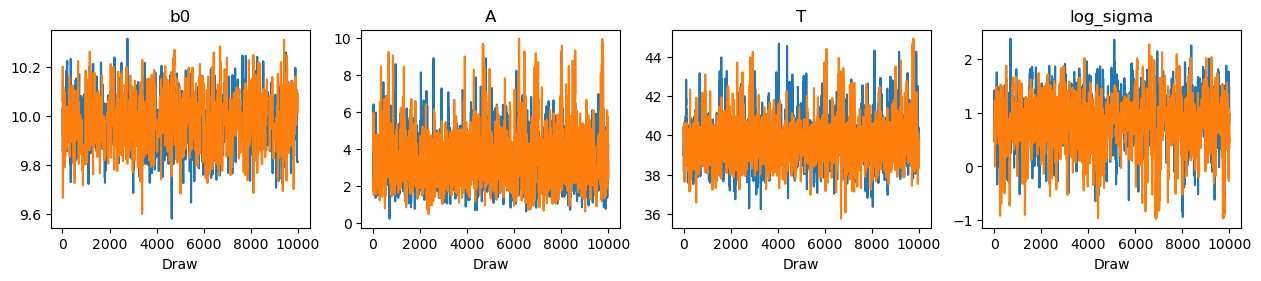

In [7]:
# compute summary statistics
summary = az.summary(traces)
# best-fit parameters (posterior means)
bf = summary["mean"]
az.plot_trace(traces)

In [8]:
b0best = float(bf['b0'])
Abest = float(bf['A'])
Tbest = float(bf['T'])
# note that we used log(sigma) in MCMCM
sigbest = np.exp(float(bf['log_sigma'])) 

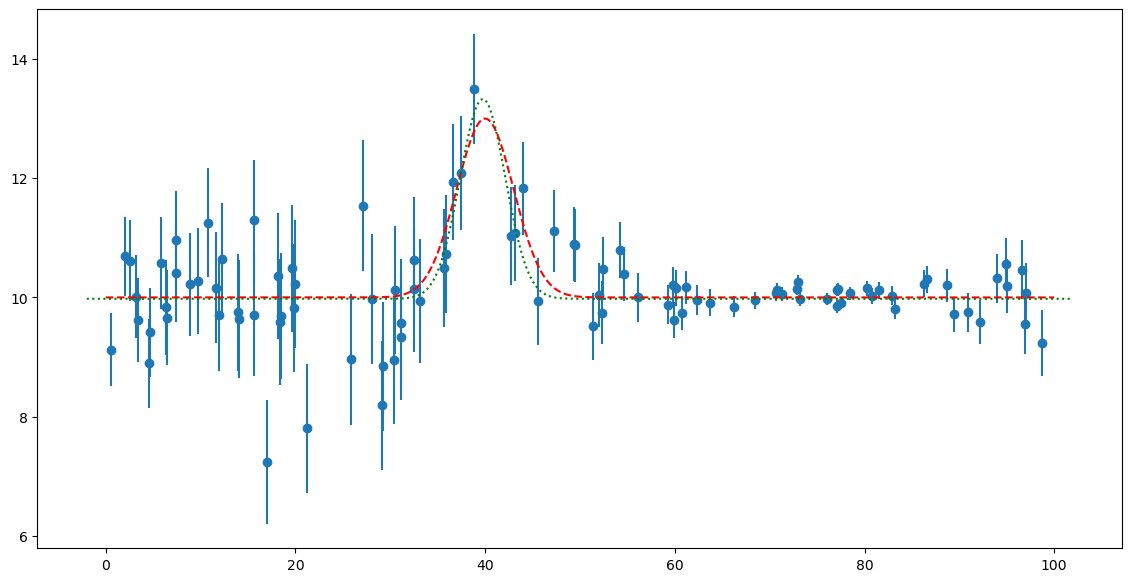

In [9]:
# and let's visualize it
plt.figure(figsize=(14, 7))

# "data" with observational errors.
plt.scatter(t, y_obs)
plt.errorbar(t, y_obs, err_y, fmt='none')

# generating model
tt = np.linspace(0, 100, 1000)
plt.gca().plot(tt, GaussAndBkgd(tt, b0_true, A_true, sigma_true, T_true), c='red', linestyle='--');

# best-fit model
tt = np.linspace(-2, 102, 1000)
plt.gca().plot(tt, GaussAndBkgd(tt, b0best, Abest, sigbest, Tbest), c='green', linestyle=':');

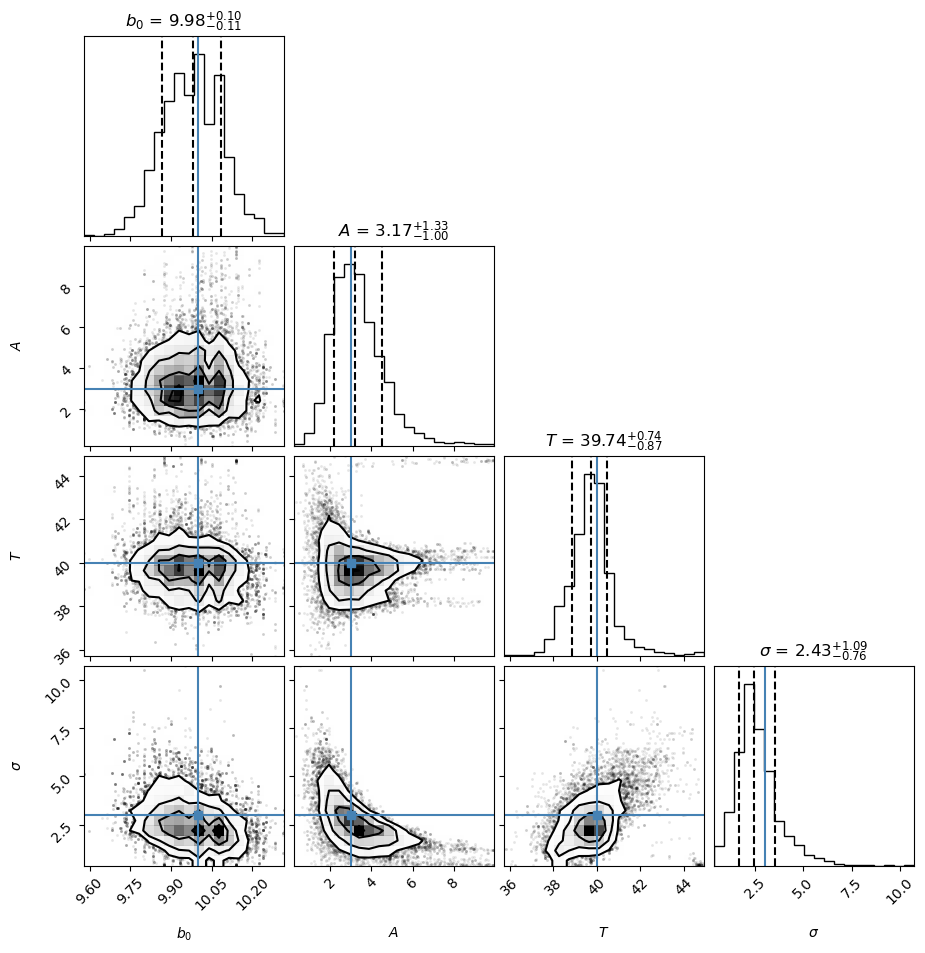

In [10]:
# extract posterior samples correctly
posterior = az.extract(
    traces,
    group="posterior", 
    var_names=['b0', 'A', 'T', 'log_sigma']
)

samples = np.vstack([
    posterior["b0"].values,
    posterior["A"].values,
    posterior["T"].values,
    np.exp(posterior["log_sigma"].values)
]).T

Ls = ['$b_0$', '$A$', '$T$', r'$\sigma$']
truth = [10, 3.0, 40.0, 3.0]

fig = corner.corner(
    samples,
    truths=truth,
    labels=Ls,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12} 
)
plt.show()

### Things to notice:
  * The fit appears reasonable. There's no indication there were issues with sampling.
  * The contours enclose $68\%$ and $95\%$ probabilities
  * Much of what's in the plot has a ready physical interpretation:
    * Note how $b_0$ is confined to a tight interval. That is because the stretch of measurements after $t > 60$, with very small error-bars, constrains it strongly.
    * Also, note how $A$ and $\sigma$ are relatively poorly constrained, but strongly correlated. You could imagine increasing $A$ to better fit the one high datapoint around $t=38$, but would have to reduce $\sigma$ (the width) so the flux falls off rapidly enough to explain the data points in the wings.

### **Studying correlations in posterior plots can bring insight into the problem, and allow us to develop intuition about which data points constrain which model parameters the most**

## Let's now see how to search for multiple bursts

In [11]:
def OneBurst(t, b0, A, T, alpha):
    """a single exponential burst model"""
    yBurst = A * np.exp(-(t-T)/alpha)
    return np.where(t > T, b0+yBurst, b0)

def TwoBursts(t, b0, A1, T1, alpha1, A2, T2, alpha2):
    """two exponential bursts model"""
    yBurst1 = A1 * np.exp(-(t-T1)/alpha1)
    yBurst2 = A2 * np.exp(-(t-T2)/alpha2)
    y1 = np.where(t > T1, b0+yBurst1, b0)
    return np.where(t > T2, y1+yBurst2, y1)

In [12]:
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)

In [13]:
# BURST: input model parameters 
b0_true = 10
A1_true = 4
T1_true = 20
alpha1_true = 10
A2_true = 5
T2_true = 70
alpha2_true = 5
thetaTrue = (b0_true, A1_true, T1_true, alpha1_true, A2_true, T2_true, alpha2_true)

# generate data
Ndata = 200
t = 120 * np.random.random(Ndata)
xdata = np.sort(t) 
y_true = TwoBursts(xdata, b0_true, A1_true, T1_true, alpha1_true, A2_true, T2_true, alpha2_true)

# add scatter to points
yErr = 0.4 + 0.1*np.sqrt(y_true)   
ydata = np.random.normal(y_true, yErr)

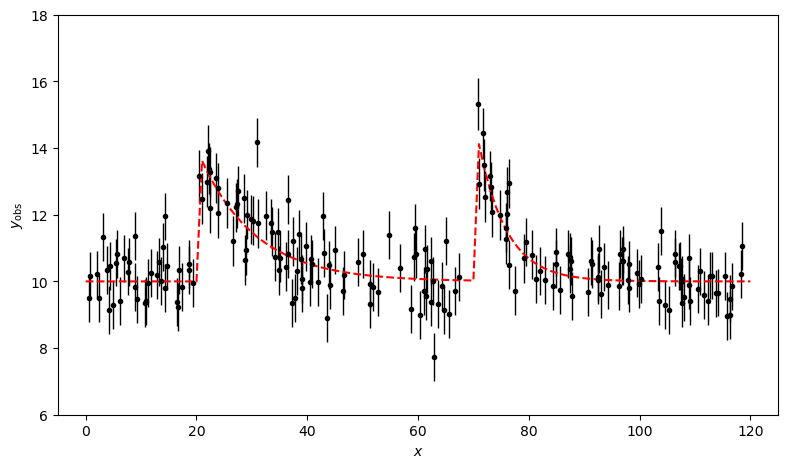

In [14]:
# Plot input data again, this time showing the true generative model
#  (which at the same time checks that the model and true params are set properly)
fig = plt.figure(figsize=(16, 16))
fig.subplots_adjust(bottom=0.1, top=0.95,
                    left=0.1, right=0.95,
                    hspace=0.05, wspace=0.05)

# Plot the model fit
ax = fig.add_axes([0.5, 0.7, 0.45, 0.25])
t_fit = np.linspace(0, 120, 121)
y_true = TwoBursts(t_fit, b0_true, A1_true, T1_true, alpha1_true, A2_true, T2_true, alpha2_true)

ax.errorbar(xdata, ydata, yErr, fmt='.', lw=1, c='k')
ax.plot(t_fit, y_true, '--', c='red')
ax.set_xlim(-5, 125)
ax.set_ylim(6.0, 18.001)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$y_{\rm obs}$')

plt.show()

In [15]:
# Define our posterior using Python functions
# for clarity, I've separated-out the prior and likelihood
# but this is not necessary. Note that emcee requires log-posterior

def yModelSingle(x, theta):
    # this is where a model is chosen, and also the number 
    # of model parameters and their meaning set 
    b0 = theta[0]
    A = theta[1]
    T = theta[2]
    alpha = theta[3]
    return OneBurst(x, b0, A, T, alpha) 

def yModelDouble(x, theta):
    # this is where a model is chosen, and also the number 
    # of model parameters and their meaning set 
    b0 = theta[0]
    A1 = theta[1]
    T1 = theta[2]
    alpha1 = theta[3]
    A2 = theta[4]
    T2 = theta[5]
    alpha2 = theta[6]
    return TwoBursts(x, b0, A1, T1, alpha1, A2, T2, alpha2) 

def yModel(x, theta):
    return yModelDouble(x, theta)

LOGPRIOR_MIN = -np.inf 
# LOGPRIOR_MIN = -1.0e12

def log_flat_prior(theta, thetaMin, thetaMax):
    # logPriorMin = -np.inf  
    for k in range(np.size(theta)):
        if (theta[k]<thetaMin[k]): return LOGPRIOR_MIN 
        if (theta[k]>thetaMax[k]): return LOGPRIOR_MIN   
    return 1.0 
    
def log_prior(theta, thetaMin, thetaMax):
    return log_flat_prior(theta, thetaMin, thetaMax)

def log_likelihood(theta, x, y, yErr):
    # we are assuming that measurement errors are Gaussian and known
    # and thus ignoring normalization factors in the likelihood
    return -np.sum((y - yModel(x, theta)) ** 2 / yErr ** 2)

def log_posterior(theta, x, y, yErr, thetaMin, thetaMax):
    logLikelihood = log_likelihood(theta, x, y, yErr)
    logPrior = log_prior(theta, thetaMin, thetaMax)
    if logPrior > LOGPRIOR_MIN:
        return logPrior + logLikelihood
    else:
        return LOGPRIOR_MIN + logLikelihood 

In [16]:
# limits for flat priors
thetaMin =  (5,  0,  0,  2,  0,  20,  2)
thetaMax = (15, 10, 60, 20, 10, 100, 15)


# emcee combines multiple "walkers", each of which is its own MCMC chain. 
# The number of trace results will be nwalkers * nsteps
ndim = 7  # number of parameters in the model
nwalkers = 100  # number of MCMC walkers
# starting guesses for parameters 
np.random.seed(0)
starting_guesses = 0.1*np.random.random((nwalkers, ndim))
# set starting guesses at the center of flat priors
for k in range(np.size(thetaMin)):
    starting_guesses[:,k] += 0.5*(thetaMin[k]+thetaMax[k])

## here we are using emcee (not pymc)

In [17]:
nburn = 10000    # "burn-in" period to let chains stabilize
nsteps = 30000  # number of MCMC steps to take, about 1 min runtime
## WARNING: this is the main step, which can take many minutes (depending on your machine)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[xdata, ydata, yErr, thetaMin, thetaMax])
%time sampler.run_mcmc(starting_guesses, nsteps) 
print("done")

CPU times: user 31.5 s, sys: 140 ms, total: 31.6 s
Wall time: 31.6 s
done


In [18]:
emcee_trace = sampler.chain[:, nburn:, :].reshape(-1, ndim).T
thetaFit= []
for k in range(ndim):
    thetaFit.append(np.median(emcee_trace[k]))
    print(thetaTrue[k], np.median(emcee_trace[k]), np.std(emcee_trace[k]), np.size(emcee_trace[k]))

10 10.040970940627398 0.13038980265114797 2000000
4 3.6870455705500382 0.8400832112783053 2000000
20 19.920174267288182 7.536098498702454 2000000
10 11.186919895897372 1.62068596765807 2000000
5 5.973874415737162 1.837494596520751 2000000
70 68.71901116316403 10.431553959379029 2000000
5 5.062210599240462 1.390711802434748 2000000


In [19]:
T1 = emcee_trace[2]
print(np.min(T1), np.median(T1), np.max(T1))

19.346555781217333 19.920174267288182 59.99298761420267


In [20]:
T2 = emcee_trace[5]
print(np.min(T2), np.median(T2), np.max(T2))

20.783482937886895 68.71901116316403 76.08328703892647


In [21]:
# for plotting chains
import corner

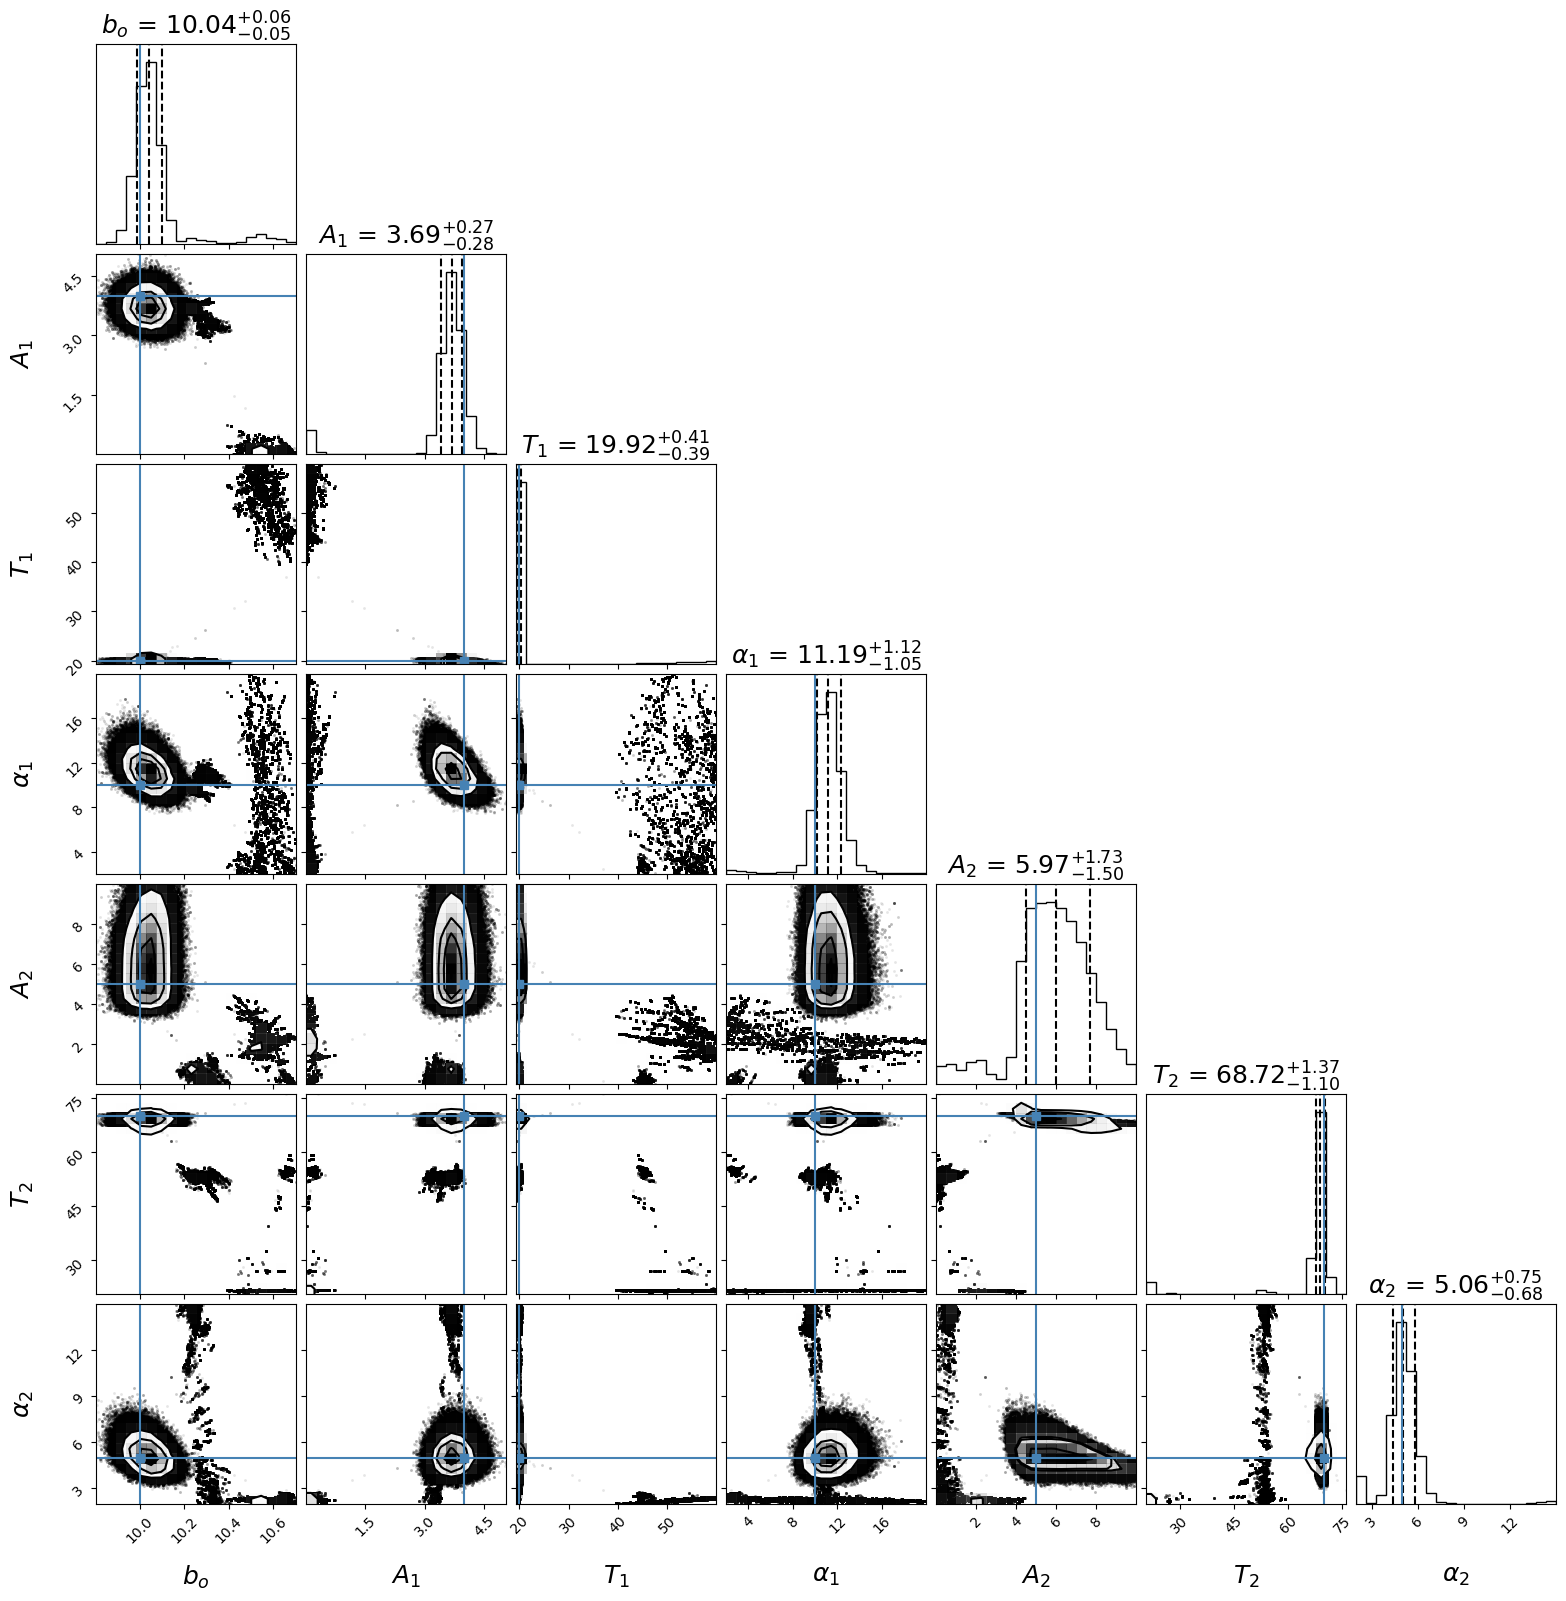

In [22]:
samples = np.vstack([emcee_trace[k] for k in range(0,ndim)]).T
Ls = [r"$b_o$", r"$A_1$", r"$T_1$", r"$\alpha_1$", r"$A_2$", r"$T_2$", r"$\alpha_2$"] 

fig = corner.corner(
    samples, 
    bins=20,
    truths=thetaTrue, 
    labels=Ls, 
    label_kwargs={"fontsize": 18}, 
    tick_kwargs={"fontsize": 38}, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 18}
)    
plt.show()

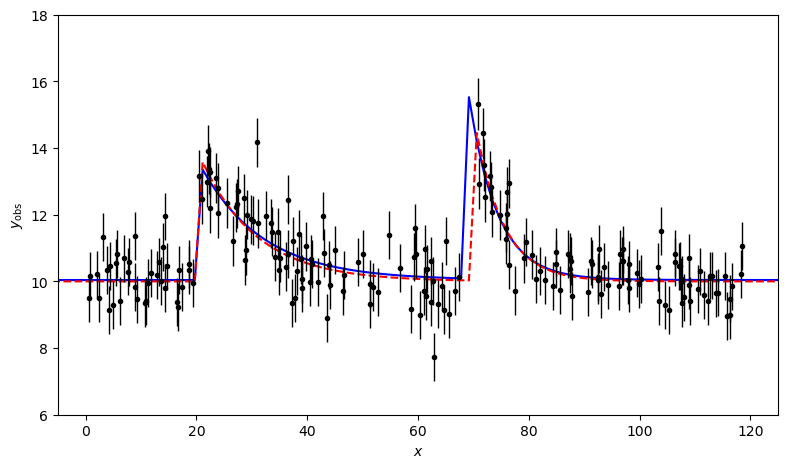

In [23]:
# Plot input data again, this time showing the true generative model
#  (which at the same time checks that the model and true params are set properly)
fig = plt.figure(figsize=(16, 16))
fig.subplots_adjust(bottom=0.1, top=0.95,
                    left=0.1, right=0.95,
                    hspace=0.05, wspace=0.05)

# Plot the model fit
ax = fig.add_axes([0.5, 0.7, 0.45, 0.25])

xfit = np.linspace(-10,130,100)
yfit = yModel(xfit, thetaFit)
yTrue = yModel(xfit, thetaTrue)
plt.plot(xfit, yfit, c='b')
plt.plot(xfit, yTrue,  '--', c='r')

ax.errorbar(xdata, ydata, yErr, fmt='.', lw=1, c='k')
ax.set_xlim(-5, 125)
ax.set_ylim(6.0, 18.001)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$y_{\rm obs}$')

plt.show()

## Now we need to: 
#### 1) find the best fit for a single-burst model
#### 2) compare BIC for the two models and decide which one is better



In [24]:
## we will need best fit for both models, so let's store the double-burst fit just in case...
thetaFitDoubleBurst = thetaFit
yfitDoubleBurst = yModel(xdata, thetaFitDoubleBurst)
chi2DoubleBurst = np.sum(((ydata-yfitDoubleBurst)/yErr)**2) 
NparamDoubleBurst = 7
BICdb = chi2DoubleBurst + NparamDoubleBurst *np.log(np.size(xdata))
print('Double Burst: chi2 =', chi2DoubleBurst, 'BIC =', BICdb)

Double Burst: chi2 = 186.76104444767975 BIC = 223.849266013516


## Let's redo emcee steps for single burst model...

In [25]:
# we will now fit "wrong" model to the same data (which was generated with a double-burst model)
def yModel(x, theta):
    return yModelSingle(x, theta)

In [26]:
# limits for flat priors
thetaMin =  (8,  0, 10,  2)
thetaMax = (12, 10, 80, 20)
ndim = 4

# starting guesses for parameters 
np.random.seed(0)
starting_guesses = 0.1*np.random.random((nwalkers, ndim))
# set starting guesses at the center of flat priors
for k in range(np.size(thetaMin)):
    starting_guesses[:,k] += 0.5*(thetaMin[k]+thetaMax[k])

In [27]:
nburn = 2000    # "burn-in" period to let chains stabilize
nsteps = 10000  # number of MCMC steps to take
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[xdata, ydata, yErr, thetaMin, thetaMax])
%time sampler.run_mcmc(starting_guesses, nsteps) 
print("done")

CPU times: user 7.35 s, sys: 28.8 ms, total: 7.37 s
Wall time: 7.37 s
done


In [28]:
emcee_trace = sampler.chain[:, nburn:, :].reshape(-1, ndim).T
thetaFit= []
for k in range(ndim):
    thetaFit.append(np.median(emcee_trace[k]))
    print(thetaTrue[k], np.median(emcee_trace[k]), np.std(emcee_trace[k]), np.size(emcee_trace[k]))

10 10.380613362948385 0.08597757117014504 800000
4 3.8242534250617237 2.0724758548292943 800000
20 20.394250561322664 24.398381010863936 800000
10 8.35330133010166 3.318465683409057 800000


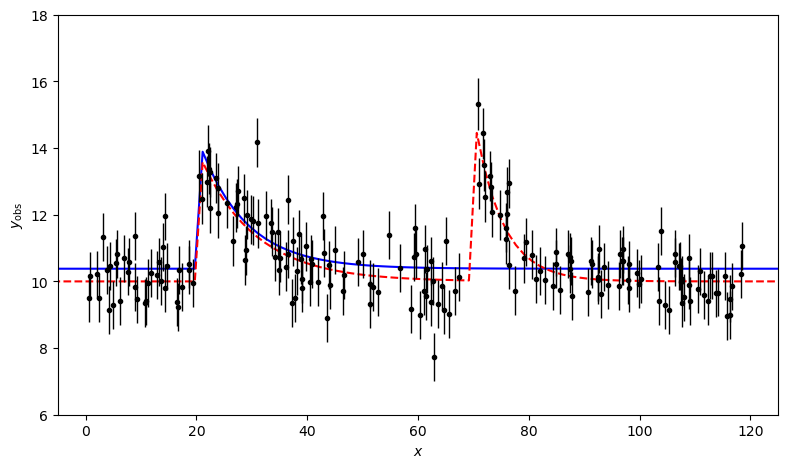

In [29]:
# Plot input data again, this time showing the true generative model
#  (which at the same time checks that the model and true params are set properly)
fig = plt.figure(figsize=(16, 16))
fig.subplots_adjust(bottom=0.1, top=0.95,
                    left=0.1, right=0.95,
                    hspace=0.05, wspace=0.05)

# Plot the model fit
ax = fig.add_axes([0.5, 0.7, 0.45, 0.25])

xfit = np.linspace(-10,130,100)
yfit = yModel(xfit, thetaFit)
plt.plot(xfit, yfit, c='b')
plt.plot(xfit, yTrue,  '--', c='r')

ax.errorbar(xdata, ydata, yErr, fmt='.', lw=1, c='k')
ax.set_xlim(-5, 125)
ax.set_ylim(6.0, 18.001)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$y_{\rm obs}$')

plt.show()

In [30]:
## let's evaluate chi2 and BIC for the single-burst fit 
thetaFitSingleBurst = thetaFit
yfitSingleBurst = yModel(xdata, thetaFitSingleBurst)
chi2SingleBurst = np.sum(((ydata-yfitSingleBurst)/yErr)**2) 
NparamSingleBurst = 4
BICsb = chi2SingleBurst + NparamSingleBurst *np.log(np.size(xdata))

In [31]:
print ("             MODEL                   CHI2            BIC")
print ('    best single burst model:', chi2SingleBurst, BICsb)
print ('    best double burst model:', chi2DoubleBurst, BICdb)

             MODEL                   CHI2            BIC
    best single burst model: 362.3681410015299 383.56141046772206
    best double burst model: 186.76104444767975 223.849266013516


## What can we do when we don't know which model for peaks to fit? 

## We use  the Bayesian Blocks Algorithm:  an excellent method for discovering bursts, particles, and other signals! 
 
## But first let's revisit histograms: Knuth's bin width for multi- model distributions 

In [ ]:
### this code taken from (and modified)
### http://www.astroml.org/book_figures/chapter5/fig_hist_binsize.html

from scipy.stats import norm
from astroML.plotting import hist as fancyhist

def plot_fancy_histogram(style, data, name, ax=None):
    if ax is not None:
        ax = plt.axes(ax)
    counts, bins, patches = fancyhist(data, bins=style, ax=ax,
                                 color='blue', histtype='stepfilled', density=True)
    # add error bars 
    bincenters = 0.5 * (bins[1:] + bins[:-1])  
    binwidth = bins[1] - bins[0]
    countsErr = np.sqrt(counts) / binwidth / np.size(xData)
    plt.errorbar(bincenters, counts, countsErr, fmt = 'none', ecolor = 'blue')

    ax.text(0.95, 0.83, '%s:\n%i bins' % (name, len(counts)),
            transform=ax.transAxes,
            ha='right', va='top', fontsize=15)
    return


### Add to a Gaussian sample of 10,000 data points with $\mu=2.0$ and $\sigma=0.2$. another sample of 10,000 data values drawn from a Cauchy distribution with $\mu=2.0$ and $\gamma=0.5$ (concatenate arrays) . 

In [33]:
# draw k=10,000 numbers from N(mu=1.0, sigma=0.2) 
# and another k=10,000 numbers from Cauchy(mu=2.0, sigma=0.5) 
np.random.seed(42)
k1 = 10000
mu = 1.0
sigma = 0.2
xDataG = norm(mu, sigma).rvs(k1)  
k2 = 10000
mu2 = 2.0 
gamma = 0.5
from scipy.stats import cauchy 
xDataC = cauchy(mu2, gamma).rvs(k2)  
xDataC = xDataC[(xDataC > -2) & (xDataC < 6)]
k = k1 + k2
xData = np.concatenate((xDataG, xDataC), axis=0)

# expected distribution
xGrid = np.linspace(-2, 6, 1000)
gaussL = norm(mu, sigma).pdf(xGrid)   
cauchyL = cauchy(mu2, gamma).pdf(xGrid)  
expectedD = (k1*gaussL + k2*cauchyL)/k

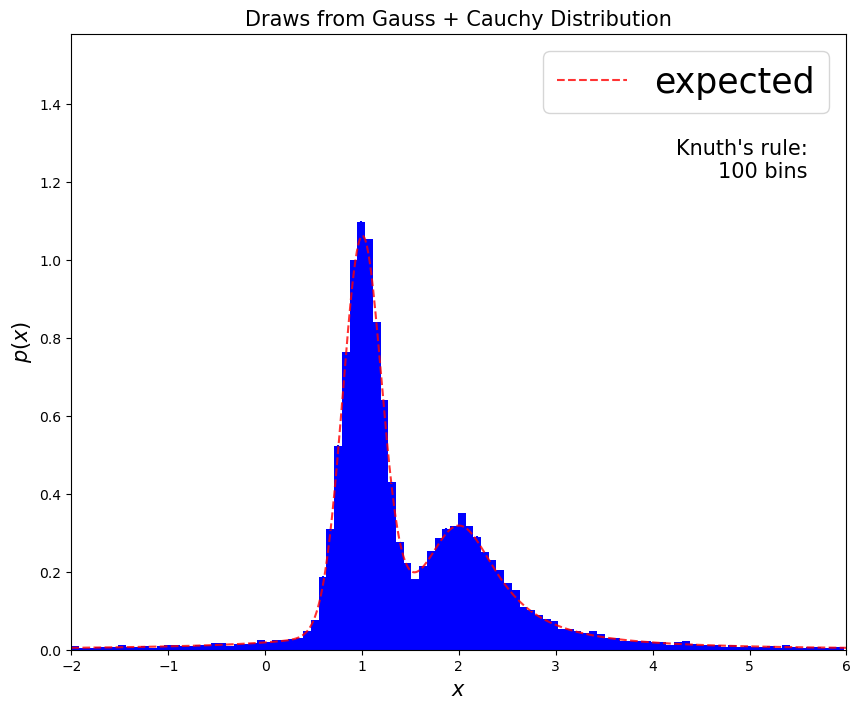

In [34]:
## now plot the histogram of values using Knuth's rule for bin width 
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(xGrid, expectedD, ls='--', c='red', label='expected', alpha = 0.8)

# histogram the data using the fancy code from astroML:
plot_fancy_histogram('knuth', xData, 'Knuth\'s rule', ax=ax)

plt.xlim(-2.0, 6.0)
yMax = 1.2/k * (k1/ np.sqrt(2*3.14) / sigma + k2/ 3.14 / gamma)
plt.ylim(0, yMax)
plt.xlabel('$x$', fontsize=15)
plt.ylabel(r'$p(x)$', fontsize=15)
plt.title('Draws from Gauss + Cauchy Distribution', fontsize=15)
plt.legend(fontsize=25)
plt.show() 

##  Bayesian Blocks Algorithm (not really an MCMC application) <a id='MS2mcmc'></a>
[Go to top](#toc)

Classical histogram methods, such as the Freedman–Diaconis and Knuth's methods,
assume a constant bin width (the former is inferior to the latter because it produces the same answer for multimodal and unimodal distributions as long as their data set size and scale parameter are the same). This limitation can be lifted by maximizing a well-designed likelihood function over bins of varying width. This approach has been dubbed Bayesian blocks. The method was first developed in the field of time-domain analysis (by Jeff Scargle), but is readily applicable to histogram data as well. 

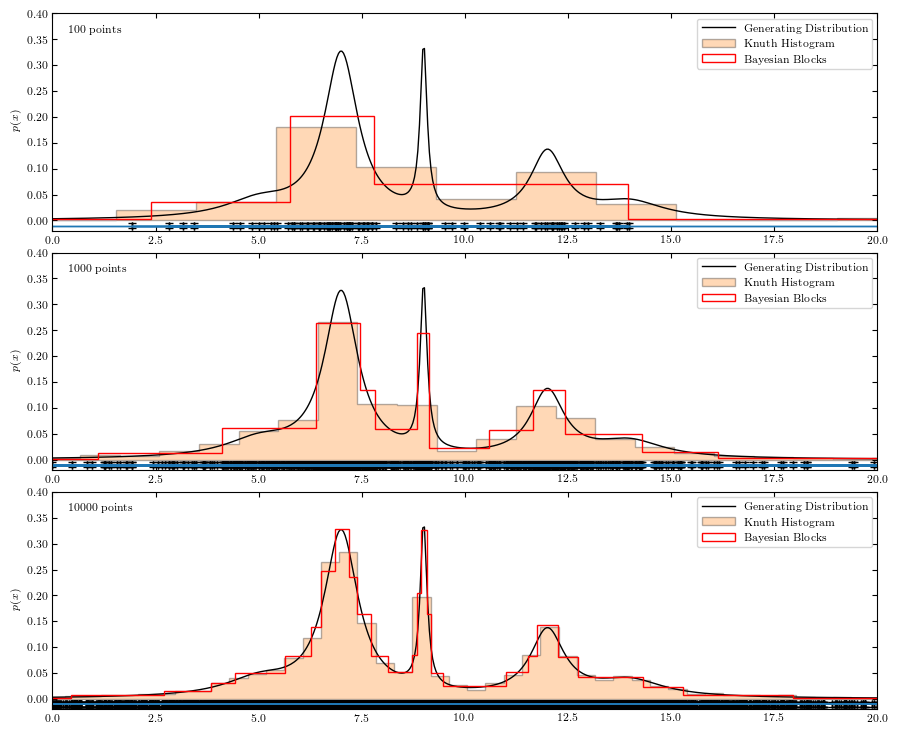

In [35]:
from scipy import stats
from astroML.plotting import hist
np.random.seed(42)
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)



# Generate sample: a mix of several Cauchy distributions
np.random.seed(0)
N = 10000
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
true_pdf = lambda x: sum([f * stats.cauchy(mu, gamma).pdf(x)
                          for (mu, gamma, f) in mu_gamma_f])
x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f * N))
                    for (mu, gamma, f) in mu_gamma_f])
np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]

#------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10,8))
fig.subplots_adjust(bottom=0.08, top=0.95, right=0.95, hspace=0.1)
N_values = (100, 1000, 10000)
subplots = (311, 312, 313)

for N, subplot in zip(N_values, subplots):
    ax = fig.add_subplot(subplot)
    xN = x[:N]
    t = np.linspace(-10, 30, 1000)

    # plot the results
    ax.errorbar(xN, -0.01 + 0*xN, xerr=0.0, yerr=0.005, ecolor='black', lw=1)
    ax.plot(t, true_pdf(t), '-', color='black', lw=1,
            label="Generating Distribution")
    ## "This is Simply the Best", if you want constant-binwidth histogram
    hist(xN, bins='knuth', ax=ax, density=True,
         histtype='stepfilled', alpha=0.3,
         label='Knuth Histogram')
    ## this is a simple call to astroML's implementation of the powerful BayBlock algo!
    hist(xN, bins='blocks', ax=ax, density=True,
         histtype='step', color='red', alpha=0.99,
         label="Bayesian Blocks")
  
    # label the plot
    ax.text(0.02, 0.95, "%i points" % N, ha='left', va='top',
            transform=ax.transAxes)
    ax.set_ylabel('$p(x)$')
    ax.legend(loc='upper right', prop=dict(size=8))

    if subplot == 212:
        ax.set_xlabel('$x$')

    ax.set_xlim(0, 20)
    ax.set_ylim(-0.02, 0.4001)

plt.show()

Note that for largest sample (N=10,000), both methods give similar results (e.g. three components are found in the data). However, for the middle dataset (N=1,000), the fixed bin width method misses the middle peak - this could be your missed Nobel prize!

[Go to top](#toc)

## Compare to Gaussian Mixture Model


### for N=1000

In [36]:
from sklearn.mixture import GaussianMixture as GMM

In [37]:
N = 1000
xN = x[:N]
X = np.vstack([xN]).T

In [38]:
# Compute GMM models & AIC/BIC
N = np.arange(1, 30)
def compute_GMM(N, covariance_type='full', max_iter=100):
    models = [None for n in N]
    for i in range(len(N)):
        models[i] = GMM(n_components=N[i], max_iter=max_iter,
                        covariance_type=covariance_type)
        models[i].fit(X)
    return models

models = compute_GMM(N)
AIC = [m.aic(X) for m in models]
BIC = [m.bic(X) for m in models]
i_best = np.argmin(BIC)
gmm_best = models[i_best]

In [39]:
print("best fit converged:", gmm_best.converged_)
print("BIC: n_components =  %i" % N[i_best])

best fit converged: True
BIC: n_components =  6


Text(0.5, 0, 'N components')

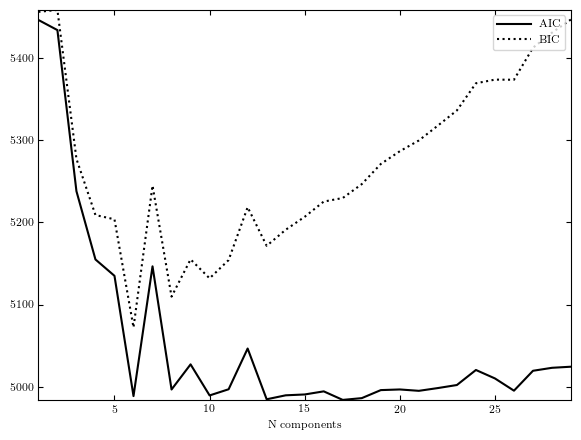

In [40]:
#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(15, 6))
fig.subplots_adjust(wspace=0.45, bottom=0.25, top=0.9, left=0.1, right=0.97)

# plot AIC/BIC
ax = fig.add_subplot(121)
ax.plot(N, AIC, '-k', label='AIC')
ax.plot(N, BIC, ':k', label='BIC')
ax.legend(loc=1)
ax.set_xlabel('N components') 

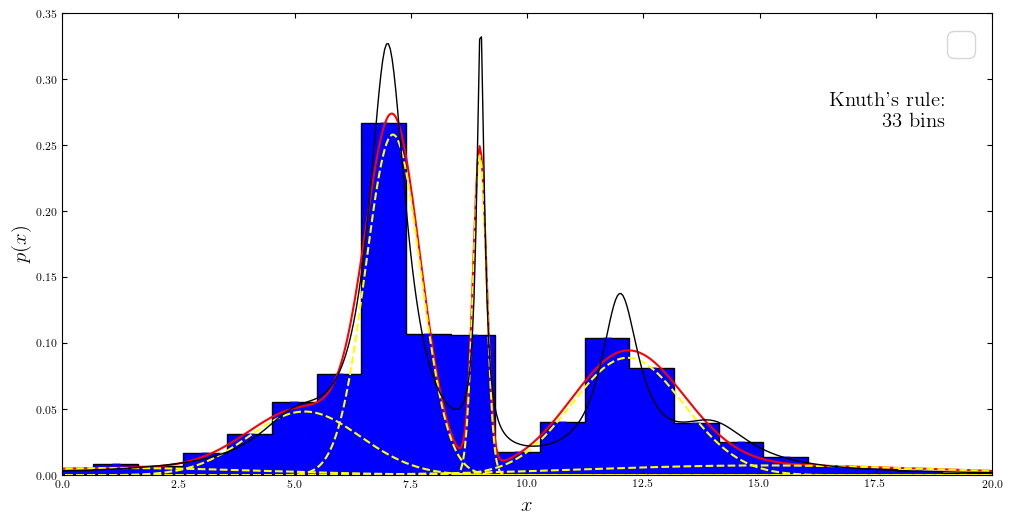

In [41]:
## now plot the histogram of values using Knuth's rule for bin width 
fig, ax = plt.subplots(figsize=(12, 6))

# histogram the data using the fancy code from astroML:
plot_fancy_histogram('knuth', xN, 'Knuth\'s rule', ax=ax)

plt.xlim(0, 20)
plt.ylim(0, 0.35)
plt.xlabel('$x$', fontsize=15)
plt.ylabel(r'$p(x)$', fontsize=15)
plt.legend(fontsize=25)

# assume `gmm` is your fitted GaussianMixture
x = np.linspace(-10, 30, 1000).reshape(-1, 1)
logprob = gmm_best.score_samples(x)
pdf = np.exp(logprob)
plt.plot(x, pdf, c='r')


weights = gmm_best.weights_
means = gmm_best.means_.flatten()
stds = np.sqrt(gmm_best.covariances_.flatten())
for w, m, s in zip(weights, means, stds):
    plt.plot(x, w * norm.pdf(x, m, s), linestyle="--", c='yellow')

# plot generating Distribution
ax.plot(t, true_pdf(t), '-', color='black', lw=1)

plt.show() 

## now generate samples with N=100, 1000 and 10000 values using uniform distribution and repeat Bayesian Blocks and GMM analysis. 